In [45]:
import os
import scipy.io as sio

oct3v1 = "/data/big_rim/rsync_dcc_sum/Oct3V1"
dannce_pred = "2024_10_31/2social_mini_20240819V1r1_femalebleach_11_48" #2024_10_14/20240916v1r1_16_37

rec_path = os.path.join(oct3v1, dannce_pred)

pred_folder = 'SDANNCE/predict00'
pred_path = os.path.join(rec_path, pred_folder, 'save_data_AVG.mat')

aw = sio.loadmat(pred_path)


In [43]:
from utlis.sync_utlis.mini_dannce_sync import load_and_reshape_com
import pandas as pd

def load_flat_predictions_simple(
    rec_path,
    pred_folder='SDANNCE/predict00',
    pred_filename='save_data_AVG.mat',
    com_folder=None,
    kp_names=None
):
    """
    Assumes predictions are already (F, A, 3, J). No shape handling.
    Flattens to DataFrame with explicit names. COM is optional fallback/add-on.

    Column order (matches memory layout of (A, 3, J)):
        For each animal a: x over all joints, then y over all joints, then z over all joints.
        Example: kp1_x_a1, kp2_x_a1, ..., kpJ_x_a1, kp1_y_a1, ..., kpJ_y_a1, kp1_z_a1, ..., kpJ_z_a1,
                 then repeat for a2, ...
    """
    # ---- predictions
    pred_path = os.path.join(rec_path, pred_folder, pred_filename)
    pred_df = None
    if os.path.exists(pred_path):
        md = sio.loadmat(pred_path)
        if 'pred' not in md:
            raise KeyError(f"'pred' not found in {pred_path}. Keys: {list(md.keys())}")
        pred = md['pred']

        # STRICT expectation: (F, A, 3, J)
        if not (pred.ndim == 4 and pred.shape[2] == 3):
            raise ValueError(f"Expected pred shape (F, A, 3, J); got {pred.shape}")

        F, A, _, J = pred.shape

        # keypoint names
        if kp_names is not None:
            if len(kp_names) != J:
                raise ValueError(f"kp_names length {len(kp_names)} != J {J}")
            kp_labels = list(kp_names)
        else:
            kp_labels = [f"kp{i+1}" for i in range(J)]

        coords = ('x', 'y', 'z')

        # flatten without reordering axes: (F, A*3*J)
        pred_flat = pred.reshape(F, A * 3 * J)

        # column names follow the actual memory order: a -> coord -> j
        pred_cols = [
            f"{kp_labels[j]}_{coords[c]}_a{a+1}"
            for a in range(A) for c in range(3) for j in range(J)
        ]
        pred_df = pd.DataFrame(pred_flat, columns=pred_cols)
        pred_df.index.name = 'frame'

    # ---- COM (optional)
    com_df = None
    # try com in (com_folder or pred_folder), then fallback to 'COM/predict00'
    for root in [com_folder or pred_folder, 'COM/predict00']:
        if root is None:
            continue
        for fname in ('com3d_used.mat', 'com3d0.mat'):
            cpath = os.path.join(rec_path, root, fname)
            if os.path.exists(cpath):
                com = load_and_reshape_com(cpath)  # (F, 3, nA)
                Fc, _, nA = com.shape
                # axis-first then animal (your original style)
                com_cols = [f'com{a+1}_{ax}' for ax in ('x', 'y', 'z') for a in range(nA)]
                com_df = pd.DataFrame(com.reshape(Fc, 3 * nA), columns=com_cols)
                com_df.index.name = 'frame'
                break
        if com_df is not None:
            break

    # ---- combine
    if pred_df is None and com_df is None:
        raise FileNotFoundError(f"No pred at {pred_path} and no COM found.")

    if pred_df is not None and com_df is not None:
        Fmin = min(len(pred_df), len(com_df))
        out = pd.concat(
            [com_df.iloc[:Fmin].reset_index(drop=True),
             pred_df.iloc[:Fmin].reset_index(drop=True)],
            axis=1
        )
        out.index.name = 'frame'
        return out

    return pred_df if pred_df is not None else com_df

In [44]:

rec_path = "/data/big_rim/rsync_dcc_sum/Oct3V1/2024_10_31/2social_mini_20240819V1r1_femalebleach_11_48"
df = load_flat_predictions_simple(rec_path, pred_folder='SDANNCE/predict00')
df.head()


,com1_x,com2_x,com1_y,com2_y,com1_z,com2_z,kp1_x_a1,kp2_x_a1,kp3_x_a1,kp4_x_a1,...,kp13_z_a2,kp14_z_a2,kp15_z_a2,kp16_z_a2,kp17_z_a2,kp18_z_a2,kp19_z_a2,kp20_z_a2,kp21_z_a2,kp22_z_a2
frame,,,,,,,,,,,,,,,,,,,,,
0,770.771103,170.329543,-191.182530,603.169428,7.781530,8.599812,760.582397,785.446411,761.496033,776.716980,...,-5.205894,-3.532380,7.191374,18.061468,-4.713904,-1.425373,4.068123,-6.269691,-2.513557,3.036495
1,770.771103,170.747971,-191.360483,603.318033,9.790893,8.718667,760.682922,785.474915,761.654602,777.263000,...,-4.995304,-3.143062,8.403817,18.877495,-4.602468,-1.768112,4.194794,-6.662390,-2.667280,3.144795
2,771.015934,170.754665,-191.465569,603.354183,9.793028,8.724699,760.614929,785.647522,761.627136,777.174988,...,-4.664139,-2.830301,8.502730,18.939726,-4.662623,-0.969204,4.134262,-6.319046,-2.254203,3.206645
3,771.111548,170.810929,-191.834927,603.407709,9.822862,8.727927,760.514832,785.800903,761.382629,777.166199,...,-4.494019,-2.922943,8.247933,18.639597,-4.549495,-1.280274,4.215627,-6.632026,-2.676429,3.261997
4,771.189240,170.962180,-191.861043,603.573906,9.824957,8.765449,760.021729,785.885254,760.893677,776.741943,...,-4.439105,-2.775522,8.146994,18.287251,-4.568086,-1.750111,4.070693,-6.911913,-3.226303,3.159082


In [5]:
import os
import scipy.io as sio
rec_path = "/data/big_rim/rsync_dcc_sum/Oct3V1/2024_10_31/2social_mini_20240819V1r1_femalebleach_11_48"
path = os.path.join(rec_path, 'yolo_tracking/predict_train_lone_social_retrain_0829/com3d0.mat')
commmm = sio.loadmat(path)


In [8]:
commmm['com'].shape

(27300, 3, 2)

In [53]:
import os, json
import numpy as np
import pandas as pd

# assumes load_flat_predictions_simple is already defined/imported

def load_flat_with_frame_map(
    rec_path,
    pred_folder='SDANNCE/predict00',
    pred_filename='save_data_AVG.mat',
    com_folder=None,
    kp_names=None,
    mapping_path=None,
    json_is_zero_based=True,   # your JSON currently is 0-based
    out_index='python'         # 'python' -> 0-based index, 'matlab' -> 1-based index
):
    """
    1) Load flattened preds/COM.
    2) Filter rows by mapped six-cam frame indices from frame_mapping.json.
    3) Optionally present 1-based frame numbering for display/interop.
    """
    df = load_flat_predictions_simple(
        rec_path,
        pred_folder=pred_folder,
        pred_filename=pred_filename,
        com_folder=com_folder,
        kp_names=kp_names
    )

    # locate mapping json (default: MIR_Aligned/frame_mapping.json)
    if mapping_path is None:
        mapping_path = os.path.join(rec_path, 'MIR_Aligned', 'frame_mapping.json')
    if not os.path.exists(mapping_path):
        # nothing to filter; just optionally reindex
        if out_index == 'matlab':
            df = df.copy()
            df.index = np.arange(1, len(df) + 1)
            df.index.name = 'frame'
        return df

    with open(mapping_path, 'r') as f:
        mp = json.load(f)

    idx = np.asarray(mp['mapped_sixcam_frame_indices'], dtype=int)
    # convert to 0-based if your JSON were 1-based
    if not json_is_zero_based:
        idx = idx - 1

    # keep only in-range positions
    in_range = (idx >= 0) & (idx < len(df))
    idx = idx[in_range]
    df_mapped = df.iloc[idx].copy()
    # keep the original six-cam frame id as a column
    df_mapped['camera_frame_sixcam'] = idx if out_index == 'python' else (idx + 1)

    # present index as requested
    if out_index == 'matlab':
        df_mapped.index = np.arange(1, len(df_mapped) + 1)
    df_mapped.index.name = 'frame'
    return df_mapped


In [54]:
oct3v1 = "/data/big_rim/rsync_dcc_sum/Oct3V1"
rec_path = os.path.join(oct3v1, "2024_10_31/2social_mini_20240819V1r1_femalebleach_11_48")

df = load_flat_with_frame_map(
    rec_path,
    pred_folder="SDANNCE/predict00",   # default
    pred_filename="save_data_AVG.mat", # default
    com_folder=None,                   # optional
    kp_names=None,                     # or your 22 names
    mapping_path=None,                 # default: MIR_Aligned/frame_mapping.json
    json_is_zero_based=True,           # your JSON uses 0-based indices
    out_index="python"                 # keep 0-based in the DataFrame
)

print(df.shape)
print(df.index[:5])              # 0-based frame index
print(df.filter(like="com1_").head(1))   # peek COM cols if present
print(df.filter(like="_a1").columns[:9]) # first few kp cols for animal 1
print(df["camera_frame_sixcam"].head())


(8247, 139)
Index([97, 100, 103, 106, 109], dtype='int64', name='frame')
           com1_x    com1_y    com1_z
frame                                
97     904.283091 -63.30449  9.346781
Index(['kp1_x_a1', 'kp2_x_a1', 'kp3_x_a1', 'kp4_x_a1', 'kp5_x_a1', 'kp6_x_a1',
       'kp7_x_a1', 'kp8_x_a1', 'kp9_x_a1'],
      dtype='object')
frame
97      97
100    100
103    103
106    106
109    109
Name: camera_frame_sixcam, dtype: int64


In [49]:
aw['pred'].shape

(25000, 2, 3, 22)

In [50]:
aw.keys()

dict_keys(['__header__', '__version__', '__globals__', 'pred', 'data', 'p_max', 'sampleID'])

In [52]:
aw['sampleID']

array([[1.0000e+00, 2.0000e+00, 3.0000e+00, ..., 2.6706e+04, 2.6707e+04,
        2.6708e+04]])

In [48]:
import os
import numpy as np
import pandas as pd
import scipy.io as sio

# assumes you already have: load_flat_predictions_simple(...)
# from the previous step (no shape handling for preds)

def validate_flatten_mapping(
    rec_path,
    pred_folder='SDANNCE/predict00',
    pred_filename='save_data_AVG.mat',
    com_folder=None,
    kp_names=None,
    frames_to_check=(0, 10, -1),
):
    """
    Validate that DataFrame columns equal raw .mat contents.
    - Assumes pred shape is exactly (F, A, 3, J).
    - Uses the same naming/order as load_flat_predictions_simple:
        preds: a -> coord -> j
        COM:   axis-first, then animal
    """

    # --- load raw pred .mat
    pred_path = os.path.join(rec_path, pred_folder, pred_filename)
    if not os.path.exists(pred_path):
        raise FileNotFoundError(f"pred file not found: {pred_path}")
    aw = sio.loadmat(pred_path)
    if 'pred' not in aw:
        raise KeyError(f"'pred' not found in {pred_path}. Keys: {list(aw.keys())}")
    pred = aw['pred']  # expected (F, A, 3, J)
    if not (pred.ndim == 4 and pred.shape[2] == 3):
        raise ValueError(f"Expected pred shape (F, A, 3, J), got {pred.shape}")
    Fp, A, _, J = pred.shape
    if kp_names is not None and len(kp_names) != J:
        raise ValueError(f"kp_names length {len(kp_names)} != J {J}")
    kp_labels = kp_names or [f"kp{i+1}" for i in range(J)]
    coords = ('x', 'y', 'z')

    # --- build df using your loader (no shape handling)

    df = load_flat_predictions_simple(
        rec_path,
        pred_folder=pred_folder,
        pred_filename=pred_filename,
        com_folder=com_folder,
        kp_names=kp_names
    )

    print(f"raw pred shape: {pred.shape}")
    print(f"df shape:       {df.shape}")

    # --- restrict to common frame count in case COM caused cropping
    F = min(Fp, len(df))
    # expected kp column order (exactly how loader builds them)
    kp_cols = [f"{kp_labels[j]}_{coords[c]}_a{a+1}" for a in range(A) for c in range(3) for j in range(J)]
    kp_cols_present = [c for c in kp_cols if c in df.columns]
    has_preds = len(kp_cols_present) == len(kp_cols)

    if has_preds:
        # vectorized full check
        arr_df = df.loc[:F-1, kp_cols].to_numpy()
        arr_pred = pred[:F].reshape(F, A * 3 * J)  # same flattening order
        ok_all = np.allclose(arr_df, arr_pred, equal_nan=True)
        print(f"[pred] full allclose: {ok_all}")

        # spot checks
        for f in frames_to_check:
            ff = (F + f) % F  # handle -1 safely
            a, j = 0, 0  # first animal / first joint as a simple probe
            for c, ax in enumerate(coords):
                col = f"{kp_labels[j]}_{ax}_a{a+1}"
                v_df = df.loc[ff, col]
                v_raw = pred[ff, a, c, j]
                print(f"[pred] frame {ff} {col}: df={v_df}  raw={v_raw}")
    else:
        print("[pred] no kp columns found in df (maybe COM-only session).")

    # --- COM validation (optional)
    # try the same search order your loader used
    com_df_ok = False
    com_data = None
    for root in [com_folder or pred_folder, 'COM/predict00']:
        if root is None:
            continue
        for fname in ('com3d_used.mat', 'com3d0.mat'):
            cpath = os.path.join(rec_path, root, fname)
            if os.path.exists(cpath):
                raw = sio.loadmat(cpath)['com']  # whatever shape; your COM loader normalizes
                # normalize minimally as in your com loader
                if raw.ndim == 3 and raw.shape[1] == 3:
                    com = raw
                elif raw.ndim == 2 and raw.shape[1] % 3 == 0:
                    n = raw.shape[1] // 3
                    com = raw.reshape(-1, 3, n)
                elif raw.ndim == 2 and raw.shape[1] == 3:
                    com = raw[:, :, np.newaxis]
                else:
                    raise ValueError(f"Unexpected COM shape {raw.shape}")
                Fc, _, nA = com.shape
                Fc = min(Fc, len(df))
                # expected COM column order (axis-first then animal)
                com_cols = [f'com{a+1}_{ax}' for ax in ('x', 'y', 'z') for a in range(nA)]
                if all(c in df.columns for c in com_cols):
                    arr_com_df = df.loc[:Fc-1, com_cols].to_numpy().reshape(Fc, 3, nA)
                    ok_com = np.allclose(arr_com_df, com[:Fc], equal_nan=True)
                    print(f"[COM] full allclose: {ok_com}  (shape raw={com.shape}, nA={nA})")
                    # spot check one element
                    if Fc > 0:
                        ff = (Fc + frames_to_check[0]) % Fc
                        for c_idx, ax in enumerate(('x','y','z')):
                            col = f"com1_{ax}"
                            v_df = df.loc[ff, col]
                            v_raw = com[ff, c_idx, 0]
                            print(f"[COM] frame {ff} {col}: df={v_df}  raw={v_raw}")
                    com_df_ok = True
                break
        if com_df_ok:
            break

    if not com_df_ok:
        print("[COM] no COM columns validated (not found or not present in df).")



oct3v1 = "/data/big_rim/rsync_dcc_sum/Oct3V1"
rec_path = os.path.join(oct3v1, "2024_10_31/2social_mini_20240819V1r1_femalebleach_11_48")

# if you used anatomical names when building df, pass the same list here
# kp_names = ['EarL','EarR','Snout', ...]  # length J

validate_flatten_mapping(
    rec_path,
    pred_folder='SDANNCE/predict00',
    pred_filename='save_data_AVG.mat',
    com_folder=None,
    kp_names=None,                  # or your list
    frames_to_check=(0, 123, -1)    # any frames you want to probe
)


raw pred shape: (25000, 2, 3, 22)
df shape:       (25000, 138)
[pred] full allclose: True
[pred] frame 0 kp1_x_a1: df=760.5823974609375  raw=760.5823974609375
[pred] frame 0 kp1_y_a1: df=-177.8011016845703  raw=-177.8011016845703
[pred] frame 0 kp1_z_a1: df=31.695478439331055  raw=31.695478439331055
[pred] frame 123 kp1_x_a1: df=947.0098876953125  raw=947.0098876953125
[pred] frame 123 kp1_y_a1: df=-52.42596435546875  raw=-52.42596435546875
[pred] frame 123 kp1_z_a1: df=20.682781219482422  raw=20.682781219482422
[pred] frame 24999 kp1_x_a1: df=872.2631225585938  raw=872.2631225585938
[pred] frame 24999 kp1_y_a1: df=504.3510437011719  raw=504.3510437011719
[pred] frame 24999 kp1_z_a1: df=28.256256103515625  raw=28.256256103515625
[COM] full allclose: True  (shape raw=(25468, 3, 2), nA=2)
[COM] frame 0 com1_x: df=770.77110257204  raw=770.77110257204
[COM] frame 0 com1_y: df=-191.1825297670906  raw=-191.1825297670906
[COM] frame 0 com1_z: df=7.781530023239533  raw=7.781530023239533


In [ ]:
import os, sys
sys.path.append(os.path.abspath('../..'))

import os
import scipy.io as sio

oct3v1 = "/data/big_rim/rsync_dcc_sum/Oct3V1"
dannce_pred = '2024_10_14/20240916v1r1_16_37'

rec_path = os.path.join(oct3v1, dannce_pred)

pred_folder = 'DANNCE/predict00'
pred_path = os.path.join(rec_path, pred_folder, 'save_data_AVG.mat')

aw = sio.loadmat(pred_path)

In [9]:
aw['pred'].shape

(27000, 1, 3, 22)

In [40]:
load_and_reshape_pred(pred_path).shape

(25000, 22, 3, 2)

# Miniscope:

In [100]:
import os, glob, json
import numpy as np
import pandas as pd
import xarray as xr


def read_mini_path(rec_path, filename='sync_to_mini_path.txt'):
    """Get miniscope root from a txt file in rec_path."""
    with open(os.path.join(rec_path, filename), 'r') as f:
        return f.read().strip()


def read_mini_path(rec_path, filename='sync_to_mini_path.txt'):
    with open(os.path.join(rec_path, filename), 'r') as f:
        return f.read().strip()

def read_miniscope_raw_timestamps(rec_path, time_col='Time Stamp (ms)'):
    mini_path = read_mini_path(rec_path)
    ts_csv = os.path.join(mini_path, 'My_V4_Miniscope', 'timeStamps.csv')
    ts_df = pd.read_csv(ts_csv)
    if time_col not in ts_df.columns:
        raise KeyError(f"Column '{time_col}' not in {ts_csv}. Got: {list(ts_df.columns)}")
    ts = ts_df[time_col].to_numpy()
    return ts  # full CSV timestamps, unmodified

def load_miniscope_signals_df_no_crop(
    mini_path,
    nc_file='wnd1500_stp700_max25_diff3.5_pnr1.1',
    time_col='Time Stamp (ms)',
    dff_percentile=20
):
    miniscope_path = os.path.join(mini_path, 'My_V4_Miniscope')
    ts_csv = os.path.join(miniscope_path, 'timeStamps.csv')

    # choose .nc
    if nc_file is not None and os.path.exists(nc_file):
        ca_file = nc_file
    elif nc_file is not None:
        ca_file = os.path.join(miniscope_path, f"minian_dataset_{nc_file}.nc")
        if not os.path.exists(ca_file):
            raise FileNotFoundError(f"No .nc from key '{nc_file}' at {ca_file}")
    else:
        nc_files = sorted(glob.glob(os.path.join(miniscope_path, '*.nc')))
        if not nc_files:
            raise FileNotFoundError(f"No .nc under {miniscope_path}")
        ca_file = nc_files[0]

    # raw timestamps (full CSV)
    ts_df = pd.read_csv(ts_csv)
    if time_col not in ts_df.columns:
        raise KeyError(f"Column '{time_col}' not in {ts_csv}. Got: {list(ts_df.columns)}")
    ts = ts_df[time_col].to_numpy()                    # length N_csv

    # Ca
    with xr.open_dataset(ca_file) as ds:
        C = ds['C'].values                              # (n_rois, n_frames)
    n_rois, n_frames = C.shape
    N_csv = ts.shape[0]

    # ΔF/F
    F0 = np.percentile(C, dff_percentile, axis=1, keepdims=True)
    F0 = np.where(F0 == 0, np.nan, F0)
    dFF = (C - F0) / F0                                 # (n_rois, n_frames)

    # allocate full-size arrays (pad with NaN if Ca shorter than CSV)
    Ca_full  = np.full((N_csv, n_rois), np.nan, dtype=float)
    dFF_full = np.full((N_csv, n_rois), np.nan, dtype=float)
    M = min(N_csv, n_frames)
    Ca_full[:M, :]  = C.T[:M, :]
    dFF_full[:M, :] = dFF.T[:M, :]

    calcium_cols = [f'calcium_roi{i}' for i in range(n_rois)]
    dff_cols     = [f'dF_F_roi{i}'    for i in range(n_rois)]
    df_ca  = pd.DataFrame(Ca_full,  index=ts, columns=calcium_cols)
    df_dff = pd.DataFrame(dFF_full, index=ts, columns=dff_cols)
    out = pd.concat([df_ca, df_dff], axis=1)
    out.index.name = 'timestamp_ms_mini'
    return out

def miniscope_mapped_to_json(
    rec_path,
    mini_path_file='sync_to_mini_path.txt',
    mapping_filename='frame_mapping.json',
    nc_file='wnd1500_stp700_max25_diff3.5_pnr1.1',
    time_col='Time Stamp (ms)',
    dff_percentile=20,
    assert_exact=True,
):
    """
    Map Miniscope Ca/ΔF/F to the miniscope timestamps listed in MIR_Aligned/frame_mapping.json.
    - Reads miniscope root from {rec_path}/{mini_path_file}
    - Uses your existing `load_miniscope_signals_df(mini_path, nc_file=...)` (not redefined here)
    - Subsets/orders rows by `mini_cam_timestamps` from the JSON
    """
    # miniscope root from txt
    with open(os.path.join(rec_path, mini_path_file), 'r') as f:
        mini_path = f.read().strip()

    # full miniscope DF indexed by miniscope timestamps
    df_full = load_miniscope_signals_df_no_crop(
        mini_path,
        nc_file=nc_file,
        time_col=time_col,
        dff_percentile=dff_percentile
    )

    # mapping json
    mapping_path = os.path.join(rec_path, 'MIR_Aligned', mapping_filename)
    with open(mapping_path, 'r') as f:
        mp = json.load(f)
    mini_ts = np.asarray(mp['mini_cam_timestamps'])

    # subset & order; keep exact timestamps
    df_map = df_full.reindex(mini_ts)
    df_map.index.name = 'timestamp_ms_mini'

    if assert_exact:
        # raise if any timestamps from JSON not found in the miniscope CSV index
        missing = df_map.index[df_map.isna().all(axis=1)]
        if len(missing) > 0:
            raise ValueError(f"{len(missing)} timestamps from JSON not found in Miniscope index. "
                             f"Example missing: {missing[:5].tolist()}")

    return df_map

def merge_pred_with_miniscope(
    rec_path,
    nc_key,
    dannce_folder='SDANNCE/predict00',
    pred_filename='save_data_AVG.mat',
    com_folder=None,
    mapping_filename='frame_mapping.json',
    save_h5=False,
    save_csv=False,
):
    """
    Merge Script A outputs:
      - Predictions/COM mapped via load_flat_with_frame_map(...)
      - Miniscope Ca and ΔF/F mapped via miniscope_mapped_to_json(...)

    Index of the merged DF = miniscope timestamps from MIR_Aligned/frame_mapping.json.
    Keeps SixCam indices in a column ('camera_frame_sixcam').

    Requirements (already defined elsewhere in your notebook):
      - load_flat_with_frame_map(...)
      - miniscope_mapped_to_json(...)
    """
    # 1) Load predictions/COM mapped to the JSON selection (still 0-based frame index here)
    df_pred = load_flat_with_frame_map(
        rec_path,
        pred_folder=dannce_folder,
        pred_filename=pred_filename,
        com_folder=com_folder,
        mapping_path=None,          # default MIR_Aligned/frame_mapping.json
        json_is_zero_based=True,
        out_index='python'
    )

    # 2) Load Miniscope signals (Ca, ΔF/F) mapped to the same JSON miniscope timestamps
    df_mini = miniscope_mapped_to_json(
        rec_path,
        mapping_filename=mapping_filename,
        nc_file=nc_key,
        assert_exact=True
    )

    # 3) Put predictions on the same miniscope-timestamp index
    import os, json, numpy as np
    with open(os.path.join(rec_path, 'MIR_Aligned', mapping_filename), 'r') as f:
        mp = json.load(f)
    mini_ts = np.asarray(mp['mini_cam_timestamps'])

    # Align lengths defensively (they should match under assert_exact=True)
    n = min(len(df_pred), len(df_mini), len(mini_ts))
    if (len(df_pred) != n) or (len(df_mini) != n):
        # keep it silent; caller can inspect shapes if desired
        df_pred = df_pred.iloc[:n].copy()
        df_mini = df_mini.iloc[:n].copy()
        mini_ts = mini_ts[:n]

    df_pred = df_pred.copy()
    df_pred.index = mini_ts
    df_pred.index.name = 'timestamp_ms_mini'

    # 4) Merge on miniscope timestamps
    merged = df_pred.join(df_mini, how='left')  # Ca/ΔF/F columns append to pred/COM

    # 5) Optional saves
    if save_h5:
        out_h5 = os.path.join(rec_path, 'MIR_Aligned',
                              f'merged_{os.path.basename(dannce_folder)}_{nc_key}.h5')
        merged.to_hdf(out_h5, key='df', mode='w')
    if save_csv:
        out_csv = os.path.join(rec_path, 'MIR_Aligned',
                               f'merged_{os.path.basename(dannce_folder)}_{nc_key}.csv')
        merged.to_csv(out_csv, index=True)

    return merged


In [101]:
merged = merge_pred_with_miniscope(
    rec_path=rec_path,
    nc_key='wnd1500_stp700_max25_diff3.5_pnr1.1',
    dannce_folder='SDANNCE/predict00',
    com_folder=None,
    save_h5=False,
    save_csv=False,
)
merged.shape, merged.index[:3]


((8247, 233), Index([-95, 10, 101], dtype='int64', name='timestamp_ms_mini'))

In [102]:
merged

,com1_x,com2_x,com1_y,com2_y,com1_z,com2_z,kp1_x_a1,kp2_x_a1,kp3_x_a1,kp4_x_a1,...,dF_F_roi37,dF_F_roi38,dF_F_roi39,dF_F_roi40,dF_F_roi41,dF_F_roi42,dF_F_roi43,dF_F_roi44,dF_F_roi45,dF_F_roi46
timestamp_ms_mini,,,,,,,,,,,,,,,,,,,,,
-95,904.283091,159.874200,-63.304490,611.745516,9.346781,13.618312,941.194519,940.736206,946.005432,923.539124,...,1.353989,-0.452786,0.335733,-0.035609,-0.234858,0.085692,-0.004129,0.898440,0.264195,-0.297730
10,904.392010,155.679840,-63.304490,618.219989,9.346781,13.698951,944.871277,942.365906,947.009644,924.335999,...,3.881087,0.094556,0.584542,0.807975,-0.307894,-0.095999,0.079272,0.787115,0.340957,-0.091577
101,904.392010,154.691856,-63.019114,621.607557,9.444453,14.380714,948.947937,944.305054,948.895447,925.734314,...,1.252190,0.541082,0.869049,1.026381,0.710232,0.574236,0.151991,0.796456,0.818317,-0.365478
200,905.009312,152.810418,-63.019114,626.467216,9.213090,14.396407,946.062622,944.483643,952.444580,925.819458,...,-0.247563,-0.047824,0.714319,1.718479,0.748595,-0.424740,1.450629,1.294352,0.807259,0.296676
308,905.009312,152.510364,-63.019114,627.752802,9.213090,15.220161,945.992554,944.437134,956.647827,926.382935,...,0.658194,0.212511,-0.067516,1.206718,0.164926,0.732339,-0.443172,0.836997,0.509538,-0.282515
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
829929,854.710702,177.240753,488.150258,641.266614,9.629919,14.538873,854.125671,877.081177,872.043213,861.256042,...,1.795921,1.116069,0.213744,1.668409,3.516237,0.578438,-0.578678,1.742755,0.952382,3.519420
830032,858.152059,177.239480,497.161171,642.479586,9.629919,14.538873,862.412354,883.598999,874.952515,864.538879,...,1.377858,0.188049,1.225857,0.647295,2.562920,-0.134616,-0.220395,1.324236,0.968111,3.521070
830131,859.382719,177.575547,498.877519,641.146051,9.424955,14.538873,870.403381,887.616577,873.214172,862.107544,...,2.460865,-0.390172,0.358851,1.251635,2.514496,-0.354798,-0.129858,1.647682,0.506178,3.669108


In [103]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_two_coms_from_pred_df(
    df: pd.DataFrame,
    smooth_window: int = 5,          # rolling window (samples); 1 = no smoothing
    threshold_mm: float = None,      # e.g., 250.0 to draw a dashed threshold; None = no line
    out_path: str = None,            # e.g., os.path.join(rec_path, 'MIR_Aligned', 'two_coms.png')
    title: str = None
):
    """
    Visualize the first two COMs (X/Y/Z) and their 3D distance using the df produced by
    load_flat_with_frame_map(...). Works even if df has no Ca columns.

    Time axis behavior:
      - If 'timestamp_ms_mini' exists as a COLUMN, use it (ms).
      - Else use the DataFrame index (frames), which is what load_flat_with_frame_map sets by default.

    Notes:
      - Expects COM columns like 'com1_x','com1_y','com1_z','com2_x','com2_y','com2_z', ...
      - If fewer than two COM triplets are present, the function prints a message and returns.
    """
    if df is None or df.empty:
        print("[SKIP] Empty df"); 
        return

    # ---- time axis
    if 'timestamp_ms_mini' in df.columns:
        time = df['timestamp_ms_mini'].to_numpy()
        t_label = "Time (ms)"
    else:
        # load_flat_with_frame_map uses a 0-based integer index named 'frame'
        time = df.index.to_numpy()
        t_label = "Frame"

    # ---- detect COM prefixes present (com1, com2, ...)
    com_prefixes = sorted({c.split('_')[0] for c in df.columns if c.startswith('com')})
    def has_xyz(p): return all(f"{p}_{ax}" in df.columns for ax in ('x','y','z'))
    com_prefixes = [p for p in com_prefixes if has_xyz(p)]

    if len(com_prefixes) < 2:
        print("[SKIP] Need at least two COMs (e.g., com1/com2) in df columns"); 
        return

    p1, p2 = com_prefixes[0], com_prefixes[1]

    # ---- optional smoothing for COM trajectories
    if smooth_window and smooth_window > 1:
        df_sm = df[[f"{p1}_x", f"{p1}_y", f"{p1}_z",
                    f"{p2}_x", f"{p2}_y", f"{p2}_z"]].rolling(
                        window=int(smooth_window), center=True, min_periods=1
                    ).mean()
    else:
        df_sm = df[[f"{p1}_x", f"{p1}_y", f"{p1}_z",
                    f"{p2}_x", f"{p2}_y", f"{p2}_z"]]

    # ---- distance (raw) and smoothed
    dx = df[f'{p1}_x'].to_numpy() - df[f'{p2}_x'].to_numpy()
    dy = df[f'{p1}_y'].to_numpy() - df[f'{p2}_y'].to_numpy()
    dz = df[f'{p1}_z'].to_numpy() - df[f'{p2}_z'].to_numpy()
    dist = np.sqrt(dx*dx + dy*dy + dz*dz)

    if smooth_window and smooth_window > 1:
        dist_sm = pd.Series(dist).rolling(
            window=int(smooth_window), center=True, min_periods=1
        ).mean().to_numpy()
    else:
        dist_sm = None

    # ---- plot
    fig = plt.figure(figsize=(15, 9))
    gs = fig.add_gridspec(nrows=3, ncols=1, height_ratios=[1.2, 1.2, 1.0])

    # Panel 1: COM1 X/Y/Z
    ax0 = fig.add_subplot(gs[0, 0])
    ax0.plot(time, df_sm[f'{p1}_x'], label=f'{p1} X')
    ax0.plot(time, df_sm[f'{p1}_y'], label=f'{p1} Y')
    ax0.plot(time, df_sm[f'{p1}_z'], label=f'{p1} Z')
    ax0.set_ylabel('Position (mm)')
    ax0.set_title(f'{p1} X/Y/Z (w={int(smooth_window)})' if smooth_window > 1 else f'{p1} X/Y/Z')
    ax0.legend(loc='upper right', fontsize=9)
    ax0.tick_params(labelbottom=False)

    # Panel 2: COM2 X/Y/Z
    ax1 = fig.add_subplot(gs[1, 0], sharex=ax0)
    ax1.plot(time, df_sm[f'{p2}_x'], label=f'{p2} X')
    ax1.plot(time, df_sm[f'{p2}_y'], label=f'{p2} Y')
    ax1.plot(time, df_sm[f'{p2}_z'], label=f'{p2} Z')
    ax1.set_ylabel('Position (mm)')
    ax1.set_title(f'{p2} X/Y/Z (w={int(smooth_window)})' if smooth_window > 1 else f'{p2} X/Y/Z')
    ax1.legend(loc='upper right', fontsize=9)
    ax1.tick_params(labelbottom=False)

    # Panel 3: Distance (raw + optional smoothed)
    ax2 = fig.add_subplot(gs[2, 0], sharex=ax0)
    ax2.plot(time, dist, lw=1.2, alpha=0.8, label='COM Distance (raw)')
    if dist_sm is not None:
        ax2.plot(time, dist_sm, lw=1.8, label=f'COM Distance (smoothed, w={int(smooth_window)})')
    if threshold_mm is not None:
        ax2.axhline(threshold_mm, ls='--', lw=1.2, color='black', label=f"Threshold = {threshold_mm:.3f} mm")
    ax2.set_ylabel('Distance (mm)')
    ax2.set_xlabel(t_label)
    ax2.set_title('COM Distance')
    ax2.legend(loc='upper right', fontsize=9)
    ax2.margins(x=0)

    if title:
        fig.suptitle(title, y=1.02, fontsize=14)

    plt.tight_layout()

    if out_path:
        try:
            fig.savefig(out_path, dpi=300)
            print(f"[OK] Saved: {out_path}")
        except Exception as e:
            print(f"[WARN] Save failed: {e}")

    plt.show()
    plt.close(fig)


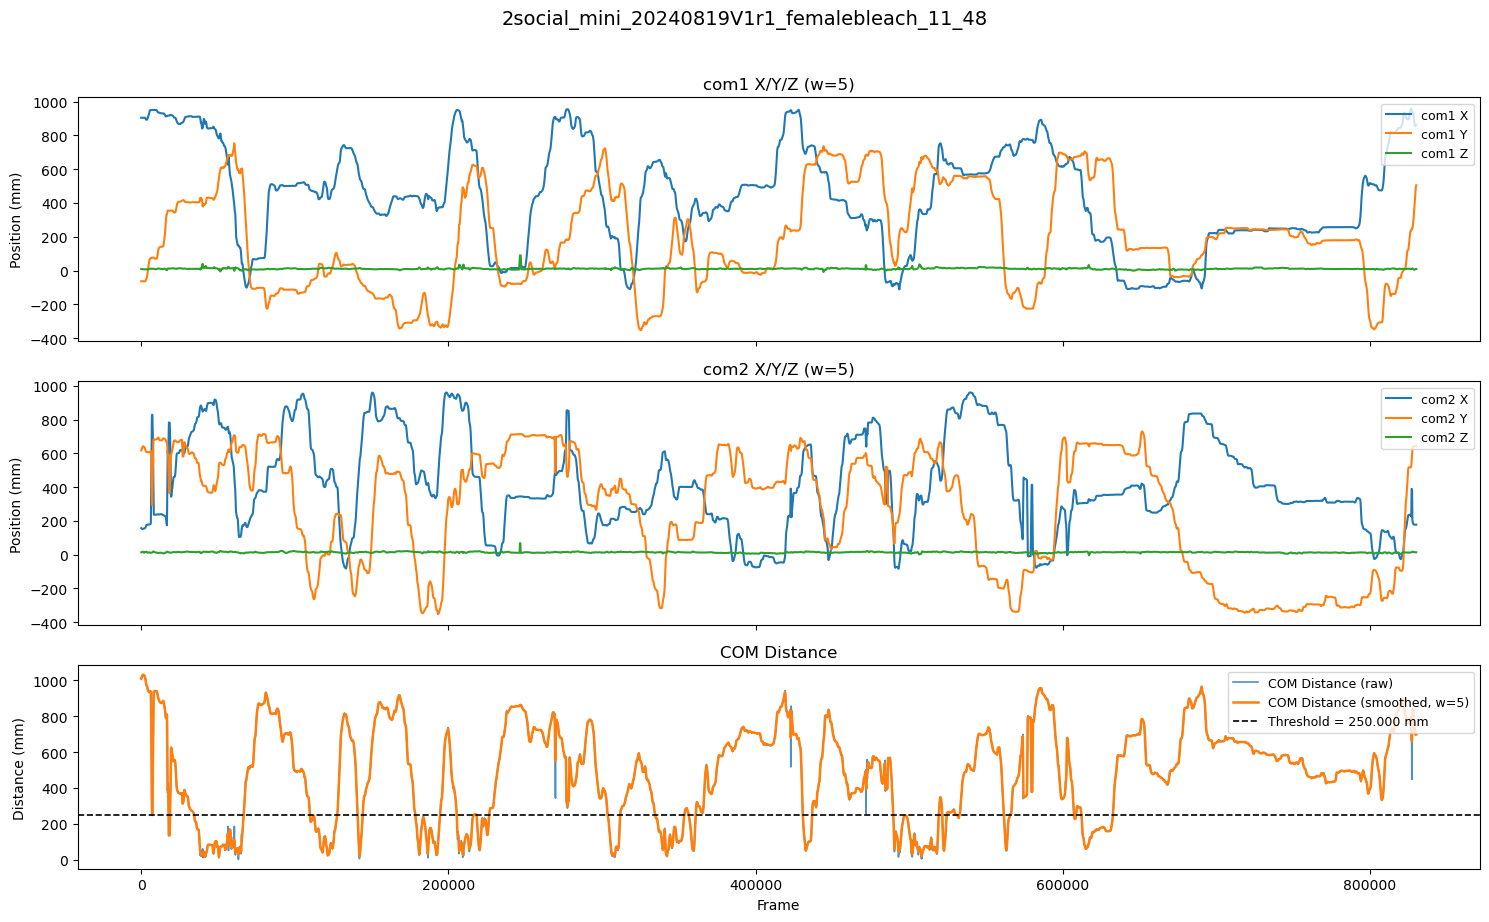

In [104]:

plot_two_coms_from_pred_df(
    merged,
    smooth_window=5,
    threshold_mm=250.0,         # or None
    out_path=None,               # or "/path/to/MIR_Aligned/two_coms.png"
    title="2social_mini_20240819V1r1_femalebleach_11_48"
)


In [85]:
json_path = "/data/big_rim/rsync_dcc_sum/Oct3V1/2024_10_31/2social_mini_20240819V1r1_femalebleach_11_48/MIR_Aligned/frame_mapping.json"

with open(json_path, 'r') as f:
    mp = json.load(f)

In [89]:
mp.keys()

dict_keys(['time_offset', 'mapped_sixcam_frame_indices', 'mini_cam_timestamps'])

In [94]:
len(mp['mapped_sixcam_frame_indices'])

8954

In [95]:
len(mp['mini_cam_timestamps'])

8954

In [96]:
import os, json
import numpy as np
import scipy.io as sio
import pandas as pd

# --- tiny helpers ------------------------------------------------------------

def read_mapping(rec_path, mapping_filename='frame_mapping.json'):
    """Return idx (np.int64) and miniscope timestamps from MIR_Aligned JSON."""
    mpath = os.path.join(rec_path, 'MIR_Aligned', mapping_filename)
    with open(mpath, 'r') as f:
        mp = json.load(f)
    idx = np.asarray(mp['mapped_sixcam_frame_indices'], dtype=np.int64)
    ts  = np.asarray(mp['mini_cam_timestamps'])
    return idx, ts, mp.get('time_offset', None)

def pred_len(rec_path, pred_folder='SDANNCE/predict00', pred_filename='save_data_AVG.mat'):
    """Length F of prediction frames (no shape handling beyond first dim)."""
    mat = sio.loadmat(os.path.join(rec_path, pred_folder, pred_filename))
    pred = mat['pred']  # expected (F, A, 3, J) or similar; first dim is frames
    return int(pred.shape[0])

def com_len(rec_path):
    """Try common COM files; return first that exists (length, path) or (None, None)."""
    candidates = [
        ('SDANNCE/predict00', 'com3d_used.mat'),
        ('COM/predict00',     'com3d0.mat'),
        ('DANNCE/predict00',  'com3d_used.mat'),
    ]
    for folder, fname in candidates:
        p = os.path.join(rec_path, folder, fname)
        if os.path.exists(p):
            arr = sio.loadmat(p)['com']
            # normalize only to read length along frames (first dim)
            if arr.ndim == 3:
                return int(arr.shape[0]), p
            if arr.ndim == 2:
                return int(arr.shape[0]), p
    return None, None

def first_offenders(idx, limit, k=10):
    """Positions where idx >= limit; return list of (pos_in_series, idx_value)."""
    bad = np.flatnonzero(idx >= limit)
    if bad.size == 0:
        return []
    take = bad[:k].tolist()
    return [(int(i), int(idx[i])) for i in take]

def summarize_mapping_vs_data(rec_path, pred_folder='SDANNCE/predict00', pred_filename='save_data_AVG.mat'):
    idx, ts, t_off = read_mapping(rec_path)
    Fp = pred_len(rec_path, pred_folder=pred_folder, pred_filename=pred_filename)
    Fc, cpath = com_len(rec_path)

    print("=== mapping.json ===")
    print(f" len(idx): {len(idx)}   min: {idx.min()}   max: {idx.max()}   (0-based assumed)")
    if t_off is not None:
        print(f" time_offset: {t_off:.3f} ms")
    print(f" len(mini_cam_timestamps): {len(ts)}")
    print(" idx monotonic:", np.all(np.diff(idx) >= 0))

    print("\n=== data lengths ===")
    print(f" preds F: {Fp}")
    if Fc is not None:
        print(f" COM   F: {Fc}   ({cpath})")
    else:
        print(" COM   F: None found")

    print("\n=== validity checks ===")
    in_pred = np.all((idx >= 0) & (idx < Fp))
    print(" all idx in preds range? ", in_pred)
    if not in_pred:
        print(" first offenders vs preds (pos_in_series, idx_value):",
              first_offenders(idx, Fp, k=10))

    if Fc is not None:
        in_com = np.all((idx >= 0) & (idx < Fc))
        print(" all idx in COM   range? ", in_com)
        if not in_com:
            print(" first offenders vs COM   (pos_in_series, idx_value):",
                  first_offenders(idx, Fc, k=10))

    # fast 0/1-based sanity probe (does subtracting 1 fix it?)
    needs_minus1_pred = np.all((idx-1 >= 0) & (idx-1 < Fp))
    print("\n if 1-based -> 0-based (idx-1) fits preds? ", needs_minus1_pred)
    if Fc is not None:
        needs_minus1_com = np.all((idx-1 >= 0) & (idx-1 < Fc))
        print(" if 1-based -> 0-based (idx-1) fits COM?   ", needs_minus1_com)

    # spacing (helps understand fps ratio)
    diffs = np.diff(idx)
    if diffs.size:
        q = np.percentile(diffs, [5, 50, 95])
        uniq, counts = np.unique(diffs[:2000], return_counts=True)
        top = sorted(zip(counts, uniq), reverse=True)[:5]
        print("\n idx step stats  (Δ idx):  p5/median/p95 =", q.tolist())
        print(" top step sizes (count, step) in head:", top)

def trim_mapping_to_fit(rec_path, prefer='preds', pred_folder='SDANNCE/predict00', pred_filename='save_data_AVG.mat',
                        out_name='frame_mapping_trimmed.json'):
    """
    Create a trimmed mapping where all indices fit the chosen target ('preds' or 'com').
    Writes MIR_Aligned/out_name. Returns path.
    """
    idx, ts, t_off = read_mapping(rec_path)
    Fp = pred_len(rec_path, pred_folder, pred_filename)
    Fc, _ = com_len(rec_path)
    if prefer == 'preds':
        lim = Fp
    elif prefer == 'com':
        if Fc is None:
            raise RuntimeError("COM length unknown; cannot trim to COM.")
        lim = Fc
    else:
        raise ValueError("prefer must be 'preds' or 'com'.")

    ok = (idx >= 0) & (idx < lim)
    idx_t = idx[ok].tolist()
    ts_t  = ts[ok].tolist()
    out = {
        "time_offset": float(t_off) if t_off is not None else None,
        "mapped_sixcam_frame_indices": idx_t,
        "mini_cam_timestamps": ts_t
    }
    out_path = os.path.join(rec_path, 'MIR_Aligned', out_name)
    with open(out_path, 'w') as f:
        json.dump(out, f, indent=2)
    print(f"trimmed mapping saved -> {out_path}  (kept {ok.sum()} / {len(ok)})")
    return out_path


In [97]:
# 1) see exactly why the assertion fired
summarize_mapping_vs_data(
    rec_path,
    pred_folder="SDANNCE/predict00",
    pred_filename="save_data_AVG.mat"
)

# 2) if the JSON was generated against a different stream (e.g., longer 6-cam, shorter COM),
#    make a trimmed copy that *fits* your current preds (or COM)
trimmed = trim_mapping_to_fit(
    rec_path,
    prefer='preds',  # or 'com'
    pred_folder="SDANNCE/predict00",
    pred_filename="save_data_AVG.mat",
    # out_name="frame_mapping_for_this_pred.json"
)


=== mapping.json ===
 len(idx): 8954   min: 97   max: 27132   (0-based assumed)
 time_offset: -3324.353 ms
 len(mini_cam_timestamps): 8954
 idx monotonic: True

=== data lengths ===
 preds F: 25000
 COM   F: 25468   (/data/big_rim/rsync_dcc_sum/Oct3V1/2024_10_31/2social_mini_20240819V1r1_femalebleach_11_48/SDANNCE/predict00/com3d_used.mat)

=== validity checks ===
 all idx in preds range?  False
 first offenders vs preds (pos_in_series, idx_value): [(8247, 25000), (8248, 25003), (8249, 25006), (8250, 25009), (8251, 25012), (8252, 25015), (8253, 25018), (8254, 25021), (8255, 25024), (8256, 25027)]
 all idx in COM   range?  False
 first offenders vs COM   (pos_in_series, idx_value): [(8402, 25468), (8403, 25471), (8404, 25474), (8405, 25477), (8406, 25480), (8407, 25483), (8408, 25486), (8409, 25489), (8410, 25492), (8411, 25495)]

 if 1-based -> 0-based (idx-1) fits preds?  False
 if 1-based -> 0-based (idx-1) fits COM?    False

 idx step stats  (Δ idx):  p5/median/p95 = [3.0, 3.0, 4.0

In [83]:
N = 5  # how many to peek

# raw miniscope timestamps (unmapped)
print("raw first ts:", df_raw_mini.index[:N].tolist())

# json list used for mapping (if you still have ts_json from earlier)
print("json first ts:", ts_json[:N].tolist())

# mapped miniscope timestamps (after reindex)
print("mapped first ts:", df_preview_mapped.index[:N].tolist())

# quick equality check on those first N
print("first N match:", np.array_equal(df_raw_mini.index[:N].to_numpy(),
                                       df_preview_mapped.index[:N].to_numpy()))


raw first ts: [-95, 10, 101, 200, 308]
json first ts: [-95, 10, 101, 200, 308]
mapped first ts: [-95, 10, 101, 200, 308]
first N match: True


In [78]:

df_mini_map

,calcium_roi0,calcium_roi1,calcium_roi2,calcium_roi3,calcium_roi4,calcium_roi5,calcium_roi6,calcium_roi7,calcium_roi8,calcium_roi9,...,dF_F_roi37,dF_F_roi38,dF_F_roi39,dF_F_roi40,dF_F_roi41,dF_F_roi42,dF_F_roi43,dF_F_roi44,dF_F_roi45,dF_F_roi46
timestamp_ms_mini,,,,,,,,,,,,,,,,,,,,,
-95,0.066881,2.077463,0.305548,0.690128,1.037228,1.070691,0.165800,0.901861,0.321576,0.976645,...,1.353989,-0.452786,0.335733,-0.035609,-0.234858,0.085692,-0.004129,0.898440,0.264195,-0.297730
10,0.414807,2.487448,0.678096,0.427948,1.759790,0.788648,0.434373,0.481540,0.316657,1.583572,...,3.881087,0.094556,0.584542,0.807975,-0.307894,-0.095999,0.079272,0.787115,0.340957,-0.091577
101,0.173973,2.162957,0.518440,0.886223,1.361992,0.976984,0.101199,1.006656,0.278565,1.939009,...,1.252190,0.541082,0.869049,1.026381,0.710232,0.574236,0.151991,0.796456,0.818317,-0.365478
200,0.280921,1.606439,0.807390,0.589963,1.630926,0.935491,0.116788,0.811002,0.363086,2.168769,...,-0.247563,-0.047824,0.714319,1.718479,0.748595,-0.424740,1.450629,1.294352,0.807259,0.296676
308,0.246280,1.566569,0.185021,0.549247,0.884358,1.126234,0.034717,0.349039,0.369803,1.598691,...,0.658194,0.212511,-0.067516,1.206718,0.164926,0.732339,-0.443172,0.836997,0.509538,-0.282515
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
901127,0.290334,7.449459,0.257948,1.146597,0.134275,0.560697,0.538524,0.040454,0.200970,14.035929,...,0.365703,2.174299,0.048821,0.179550,-0.354903,0.745782,1.615400,0.554377,0.078860,0.569858
901230,0.636536,7.404739,0.217015,1.199594,-0.008947,0.684568,0.296759,0.168413,0.495239,12.454814,...,2.293121,1.428288,1.481241,0.639848,0.329732,0.512287,1.753337,1.300725,-0.012746,0.864722
901333,0.422850,7.627974,0.106301,0.633058,0.112242,0.689755,0.700301,0.106191,0.476700,13.640642,...,2.451468,3.934044,2.501420,0.550767,0.974120,0.464583,1.534929,0.969469,0.785356,0.412192


In [60]:
mini_path_file = os.path.join(rec_path, 'sync_to_mini_path.txt')
mini_path = open(mini_path_file, 'r').read().strip()


# 1) just miniscope Ca + ΔF/F by timestamp
df_mini = load_miniscope_signals_df(mini_path)
print(df_mini.shape, df_mini.index.name)

# # 2) preds/COM reindexed by miniscope timestamps from mapping
# df_preds = preds_mapped_to_miniscope_ts(rec_path, pred_folder="SDANNCE/predict00")
# print(df_preds.shape, df_preds.index.name, df_preds.columns[:8])

# 3) merged table (timestamp index)
out = merge_preds_miniscope(
    rec_path, mini_path,
    pred_folder="SDANNCE/predict00",
    nc_file= "wnd1500_stp700_max25_diff3.5_pnr1.1", #"wnd1500_stp700_max15_diff3.5_pnrauto",  # optional
    # save_csv_path=os.path.join(rec_path, "MIR_Aligned", "preds_miniscope_merged.csv")
)
print(out.shape)
print(out.filter(like="dF_F_roi").columns[:6])  # quick peek ΔF/F columns

(8954, 22) timestamp_ms_mini
(8247, 233)
Index(['dF_F_roi0', 'dF_F_roi1', 'dF_F_roi2', 'dF_F_roi3', 'dF_F_roi4',
       'dF_F_roi5'],
      dtype='object')


In [72]:
df_mini = miniscope_mapped_to_json(rec_path, nc_file='wnd1500_stp700_max25_diff3.5_pnr1.1')  # uses mini_path.txt + mapping json

print("df_mini shape:", df_mini.shape)
print("timestamps identical:", np.array_equal(df_mini.index.values, df_preds.index.values))

# basic sanity on Ca/ΔF/F columns
assert any(col.startswith("calcium_roi") for col in df_mini.columns)
assert any(col.startswith("dF_F_roi") for col in df_mini.columns)


df_mini shape: (8954, 94)
timestamps identical: False


In [59]:
df_mini

,calcium_roi0,calcium_roi1,calcium_roi2,calcium_roi3,calcium_roi4,calcium_roi5,calcium_roi6,calcium_roi7,calcium_roi8,calcium_roi9,...,dF_F_roi1,dF_F_roi2,dF_F_roi3,dF_F_roi4,dF_F_roi5,dF_F_roi6,dF_F_roi7,dF_F_roi8,dF_F_roi9,dF_F_roi10
timestamp_ms_mini,,,,,,,,,,,,,,,,,,,,,
-95,1.213777,0.761145,0.505286,1.916716,0.427616,0.185396,0.659566,0.745649,0.011725,0.137982,...,2.323269,3.626510,0.023030,-0.171687,0.037168,0.117316,2.416557,-0.872250,0.069275,-0.530290
10,1.766278,0.940207,0.264099,2.579691,0.799581,0.164360,0.802915,0.746369,0.078359,0.053846,...,3.105078,1.418152,0.376887,0.548826,-0.080510,0.360150,2.419857,-0.146235,-0.582727,-0.167438
101,1.551959,0.812158,0.182177,2.873370,0.784449,0.222120,0.482111,0.762969,0.151880,0.223636,...,2.545999,0.668057,0.533636,0.519516,0.242616,-0.183297,2.495917,0.654818,0.733044,-0.105121
200,1.137392,1.002428,0.287082,2.609365,0.830649,0.283792,0.540632,0.802546,0.244638,0.280464,...,3.376745,1.628584,0.392725,0.609007,0.587632,-0.084162,2.677257,1.665477,1.173427,0.647714
308,0.812064,0.463839,0.338397,1.531440,0.461394,0.142296,0.418084,0.735469,0.203226,0.179646,...,1.025187,2.098437,-0.182608,-0.106257,-0.203945,-0.291758,2.369912,1.214264,0.392148,-0.473770
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
901127,4.965995,0.166584,0.084771,9.926683,0.939798,0.153676,0.888564,0.328384,0.419219,0.095910,...,-0.272669,-0.223822,4.298279,0.820433,-0.140283,0.505241,0.504650,3.567641,-0.256753,1.475469
901230,5.152422,0.152968,0.058362,8.084379,1.742662,0.340668,0.885863,0.435030,0.579289,0.237294,...,-0.332121,-0.465622,3.314966,2.375620,0.905818,0.500666,0.993302,5.311696,0.838888,2.160653
901333,5.074847,0.019229,0.152772,8.500205,1.716794,0.198360,1.005246,0.335675,0.757331,0.479247,...,-0.916044,0.398818,3.536909,2.325513,0.109694,0.702903,0.538061,7.251564,2.713876,1.218141
